In [ ]:
!pip install torch transformers sentence-transformers datasets evaluate mabwiser rank_bm25
!pip install faiss-cpu --no-cache
!pip install mabwiser --no-cache-dir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
import faiss
import sentence_transformers
import mabwiser

print("Torch version:", torch.__version__)
print("FAISS version:", faiss.__version__)
print("Sentence-Transformers version:", sentence_transformers.__version__)


Torch version: 2.6.0+cu124
FAISS version: 1.11.0
Sentence-Transformers version: 3.4.1


In [ ]:
import random
import numpy as np

random.seed(1)          # control Python's randomness
np.random.seed(1)       # control NumPy's randomness

In [ ]:

from datasets import load_dataset
dataset = load_dataset("sentence-transformers/natural-questions", split="train[:5300]")

# Extract relevant fields
documents = [d["answer"] for d in dataset]
questions = [d["query"] for d in dataset]
# documents = [d["answer"] for d in dataset]  # Shorter passages ******

print(f"Loaded {len(documents)} documents and {len(questions)} questions.")
print("Example Question:", questions[0])
print("Example Document:", documents[0][:300], "...")

README.md:   0%|          | 0.00/2.28k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


train-00000-of-00001.parquet:   0%|          | 0.00/44.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100231 [00:00<?, ? examples/s]

Loaded 5000 documents and 5000 questions.
Example Question: when did richmond last play in a preliminary final
Example Document: Richmond Football Club Richmond began 2017 with 5 straight wins, a feat it had not achieved since 1995. A series of close losses hampered the Tigers throughout the middle of the season, including a 5-point loss to the Western Bulldogs, 2-point loss to Fremantle, and a 3-point loss to the Giants. Ric ...


In [ ]:
import re
from rank_bm25 import BM25Okapi

# Preprocessing function (Tokenize documents)
def preprocess(text):
    return [word.lower() for word in re.findall(r'\w+', text)]

# Tokenize all documents for BM25
tokenized_docs = [preprocess(doc) for doc in documents]

# Initialize BM25 model

bm25 = BM25Okapi(tokenized_docs)

print("BM25 Indexing Complete!")


BM25 Indexing Complete!


# **Some Hyperparams**

In [ ]:
BETA = 0.0005

# Shared training size for all models
TRAINING_SIZE = 5000
TEST_SIZE = 300

# discrete action space
TOP_K_VALUES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
LAMBDA_VALUES = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
TAU_VALUES = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
#TOP_K_VALUES = [1, 3, 5, 7, 10]
#LAMBDA_VALUES = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
#TAU_VALUES = [0.6, 0.65, 0.7, 0.75]

# **Training set**

In [ ]:
from tqdm import tqdm
import random

# Generate initial training data using random actions
train_queries = random.sample(questions, TRAINING_SIZE)

In [ ]:
import faiss
import torch
from sentence_transformers import SentenceTransformer

# Load a sentence-transformer model
dense_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
#sentence-transformers/msmarco-MiniLM-L12-cos-v5
# sentence-transformers/all-MiniLM-L6-v2

# Compute dense embeddings for the corpus
corpus_embeddings = dense_model.encode(documents, convert_to_tensor=True)

# Create a FAISS index for fast retrieval
faiss_index = faiss.IndexFlatL2(corpus_embeddings.shape[1])
faiss_index.add(corpus_embeddings.cpu().numpy())

print("Dense Retrieval Index Built!")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Dense Retrieval Index Built!


# **Pre-encode**

In [ ]:
from tqdm import tqdm
import numpy as np

# Document Embeddings (Batched)
print("Encoding documents (batched)...")
encode_batch_size = 32
doc_embeddings = []

for i in tqdm(range(0, len(documents), encode_batch_size), desc="Documents"):
    batch = documents[i:i+encode_batch_size]
    embs = dense_model.encode(batch, normalize_embeddings=True)
    doc_embeddings.append(embs)

doc_embeddings = np.vstack(doc_embeddings)
doc_idx_map = {doc: i for i, doc in enumerate(documents)}

# Query Embeddings (Batched)
print("Encoding training queries (batched)...")
query_embeddings = []

for i in tqdm(range(0, len(train_queries), encode_batch_size), desc="Queries"):
    batch = train_queries[i:i+encode_batch_size]
    embs = dense_model.encode(batch, normalize_embeddings=True)
    query_embeddings.append(embs)

query_embeddings = np.vstack(query_embeddings)



Encoding documents (batched)...


Documents: 100%|██████████| 157/157 [00:10<00:00, 15.10it/s]


Encoding training queries (batched)...


Queries: 100%|██████████| 125/125 [00:01<00:00, 120.58it/s]


# **Hybrid retrieval function**

In [ ]:
from heapq import nlargest

def hybrid_retrieve(query, top_k, lambda_weight,
                    query_embedding=None, doc_embeddings=None, doc_idx_map=None):
    # BM25 retrieval
    query_tokens = preprocess(query)
    bm25_indices = bm25_top_k(query_tokens, bm25, top_k * 2)

    bm25_max_rank = len(bm25_indices) - 1
    bm25_scores = {
        idx: 1 - (rank / bm25_max_rank) if bm25_max_rank > 0 else 1.0
        for rank, idx in enumerate(bm25_indices)
    }

    # Dense retrieval
    if query_embedding is None:
        query_embedding = dense_model.encode([query])[0]
        query_embedding = query_embedding / np.linalg.norm(query_embedding)

    if doc_embeddings is not None:
        sims = np.dot(doc_embeddings, query_embedding)
        dense_indices = np.argsort(sims)[-top_k * 2:][::-1]
        dense_scores = {idx: sims[idx] for idx in dense_indices}
    else:
        query_tensor = dense_model.encode([query], convert_to_tensor=True)
        _, dense_indices = faiss_index.search(query_tensor.cpu().numpy(), k=top_k * 2)
        dense_indices = dense_indices[0].tolist()
        dense_scores = {idx: 1.0 for idx in dense_indices}

    # Combine scores
    all_indices = set(bm25_scores) | set(dense_scores)
    hybrid_scores = {
        idx: lambda_weight * bm25_scores.get(idx, 0) + (1 - lambda_weight) * dense_scores.get(idx, 0)
        for idx in all_indices
    }

    # Return top-k documents
    sorted_indices = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)
    return [documents[idx] for idx, _ in sorted_indices[:top_k]]



from heapq import nlargest

def bm25_top_k(query_tokens, bm25_model, k):
    scores = bm25_model.get_scores(query_tokens)
    return np.argsort(scores)[-k:][::-1].tolist()



**Simple test**

In [ ]:
import random

# Select a random query from the dataset
query_index = random.randint(0, len(questions) - 1)  # Pick a random question
query = questions[query_index]  # Fetch the query
ground_truth_document = documents[query_index]  # The corresponding document (for reference)

print(f"Query: {query}")

# Perform hybrid retrieval
#retrieved_docs = hybrid_retrieve(query, top_k=3, lambda_weight=0.6)
retrieved_docs = hybrid_retrieve(query, top_k=3, lambda_weight=0.6, doc_embeddings=doc_embeddings, doc_idx_map=doc_idx_map)

# Display retrieved documents
for i, doc in enumerate(retrieved_docs):
    print(f"\nTop {i+1} Retrieved Document:\n{doc[:300]}...")

# Optional: Compare with ground truth
print("\nGround Truth Document:\n", ground_truth_document[:300], "...")


Query: who holds the longest note in a song

Top 1 Retrieved Document:
Lovely Day (song) Toward the end of the song, Withers holds a note for 18 seconds. This is believed to be the second-longest note in UK chart history; Morten Harket of A-ha's 20-second note in "Summer Moved On" is the longest. Withers' note is sustained in chest voice, whereas Harket utilizes the fa...

Top 2 Retrieved Document:
WWE Championship The WWE Championship was the first world championship introduced into the promotion in 1963. The inaugural champion was Buddy Rogers, and there have been 50 different official champions overall and 11 vacancies.[2] The longest reigning champion is Bruno Sammartino, who held the titl...

Top 3 Retrieved Document:
The Young and the Restless cast members The Young and the Restless is an American television soap opera, created by William J. Bell and Lee Phillip Bell for CBS. It first aired on March 26, 1973. The longest-running current cast member is Doug Davidson, who has portr

# **Retrieval evaluation functions**

In [ ]:
import numpy as np

def evaluate_retrieval(query, top_k, lambda_weight, tau, beta=BETA,
                       query_embedding=None, doc_embeddings=None, doc_idx_map=None):# beta=0.0002

    retrieved_docs = hybrid_retrieve(
        query, top_k, lambda_weight,
        query_embedding=query_embedding,
        doc_embeddings=doc_embeddings,
        doc_idx_map=doc_idx_map
    )
    #retrieved_docs = hybrid_retrieve(query, top_k=top_k, lambda_weight=lambda_weight)

    ground_truth_doc = documents[questions.index(query)]

    alpha = 1-beta

    # Simple relevance score: max similarity with ground truth
    def simple_overlap(doc1, doc2):
        tokens1 = set(doc1.lower().split())
        tokens2 = set(doc2.lower().split())
        return len(tokens1 & tokens2) / len(tokens1 | tokens2)

    overlaps = [(doc, simple_overlap(doc, ground_truth_doc)) for doc in retrieved_docs]
    filtered = [doc for doc, sim in overlaps if sim >= tau]
    relevance_score = max([sim for _, sim in overlaps if sim >= tau], default=0)
    token_cost = sum(len(doc.split()) for doc in filtered)

    diversity_score = len(set(doc[:30] for doc in filtered)) / (len(filtered) + 1e-6)

    penalty_k = 0.01 * (10 - top_k)  # encourage higher k
    penalty_tau = 0.05 * (0.8 - tau)
    #normalized_cost = token_cost/top_k
    normalized_cost = token_cost

    # reward
    '''reward = (
        alpha * relevance_score +            # relevance
        0.2 * diversity_score -              # encourage diverse docs
        beta * token_cost                    # discourage long answers
    )'''

    reward = alpha * relevance_score - beta * normalized_cost - penalty_tau
    #reward = alpha * relevance_score - beta * token_cost
    #reward = relevance_score

    return reward, relevance_score, token_cost



In [ ]:
from multiprocessing import Pool

def evaluate_query_worker(args):
    query, query_embedding, action, beta = args

    # Determine if action is an index or tuple
    if isinstance(action, int):  # MAB or CMAB
        top_k, lambda_weight, tau = action_map[action]
    else:  # PPO: directly use the tuple
        top_k, lambda_weight, tau = action

    reward, score, token_cost = evaluate_retrieval(
        query=query,
        top_k=top_k,
        lambda_weight=lambda_weight,
        tau=tau,
        beta=beta,
        query_embedding=query_embedding,
        doc_embeddings=doc_embeddings,
        doc_idx_map=doc_idx_map
    )
    return action, reward, score, token_cost



def parallel_evaluate(queries, query_embeddings, actions=None, beta=BETA, num_workers=4):
    args = []

    if actions is None:
        # MAB/CMAB training — sample random discrete action_id
        actions = [random.choice(list(action_map.keys())) for _ in queries]

    for i in range(len(queries)):
        args.append((queries[i], query_embeddings[i], actions[i], beta))

    results = []
    with Pool(num_workers) as pool:
        for out in tqdm(pool.imap_unordered(evaluate_query_worker, args), total=len(args)):
            results.append(out)

    selected_actions = [r[0] for r in results]  # int for MAB/CMAB, tuple for PPO
    rewards = [r[1] for r in results]
    scores = [r[2] for r in results]

    return selected_actions, rewards, scores




# **Training**

# **MAB with Eps-Greedy (No Context)**

In [ ]:
from mabwiser.mab import MAB, LearningPolicy
import random
import numpy as np
from tqdm import tqdm

# Initialize the MAB model
from mabwiser.mab import MAB, LearningPolicy
import random
from torch.distributions import Categorical, Normal

def binarize_reward(reward, threshold=0.75):
    """Convert numerical reward to binary (1 if above threshold, else 0)."""
    return 1 if reward >= threshold else 0


# Create indexed action map
action_map = {
    idx: (k, lam, tau)
    for idx, (k, lam, tau) in enumerate(
        (k, lam, tau) for k in TOP_K_VALUES for lam in LAMBDA_VALUES for tau in TAU_VALUES
    )
}
actions = list(action_map.keys())

# Define retrieval action space
actions = list(range(len(action_map)))  # Available action indices

# Training history (store decisions as scalars)
selected_actions, rewards = [], []

scores = []

print("Starting MAB training...")
print("Using parallel reward evaluation...")
selected_actions, rewards, scores = parallel_evaluate(
    queries=train_queries,
    query_embeddings=query_embeddings,
    beta=BETA,
    num_workers=16
)


# for query in tqdm(train_queries):
#     action_id = random.choice(actions)  # Random action selection
#     top_k, lambda_weight, tau = action_map[action_id]

#     # Evaluate raw reward (relevance vs token cost tradeoff)
#     reward, score = evaluate_retrieval(
#         query, top_k, lambda_weight, tau,
#         query_embedding=query_embeddings[i],
#         doc_embeddings=doc_embeddings,
#         doc_idx_map=doc_idx_map
#     )
#     #reward, score = evaluate_retrieval(query, top_k, lambda_weight, tau)

#     # Store training data
#     history_X.append(action_id)
#     history_y.append(reward)
#     scores.append(score)


#mab = MAB(arms=actions, learning_policy=LearningPolicy.EpsilonGreedy(epsilon=0.1))
mab = MAB(arms=list(action_map.keys()), learning_policy=LearningPolicy.EpsilonGreedy(epsilon=0.05))

#mab = MAB(arms=actions, learning_policy=LearningPolicy.ThompsonSampling())


# Train MAB model using initial data
mab.fit(np.array(selected_actions), np.array(rewards))


print(f"MAB Training Completed")
print(f"→ Avg. Reward: {np.mean(rewards):.4f}")
print(f"→ Avg. Relevance Score: {np.mean(scores):.4f}")



Starting MAB training...
Using parallel reward evaluation...


100%|██████████| 4000/4000 [01:20<00:00, 49.87it/s]

MAB Training Completed
→ Avg. Reward: 0.8692
→ Avg. Relevance Score: 0.9279


# **Contextual Bandits (LinUCB)**

**Parallel reward computation**

In [ ]:
import random
import numpy as np
from mabwiser.mab import MAB, LearningPolicy
from tqdm import tqdm

from sklearn.decomposition import PCA


def get_query_features(query, query_embedding):
    length = len(query.split())
    diversity = len(set(query.lower().split())) / (length + 1e-5)
    first_word = query.strip().split()[0].lower() if query else ""
    type_flags = [1 if first_word == qtype else 0 for qtype in ["what", "who", "when", "where", "why", "how"]]

    return np.concatenate([query_embedding, [length / 10.0, diversity ] + type_flags])



# Create indexed action map
action_map = {
    idx: (k, lam, tau)
    for idx, (k, lam, tau) in enumerate(
        (k, lam, tau) for k in TOP_K_VALUES for lam in LAMBDA_VALUES for tau in TAU_VALUES
    )
}
actions = list(action_map.keys())

# Initialize contextual MAB using LinUCB
contextual_mab = MAB(
    arms=actions,
    learning_policy=LearningPolicy.LinUCB(alpha=1.0)
)

print("Starting Contextual MAB training...")
sampled_actions = [random.choice(actions) for _ in train_queries]

# Run parallel evaluation
arms, rewards, scores = parallel_evaluate(
    queries=train_queries,
    query_embeddings=query_embeddings,
    actions=sampled_actions,
    beta=BETA,
    num_workers=16
)

from sklearn.decomposition import PCA

pca_cmab = PCA(n_components=32)
query_embeddings_reduced = pca_cmab.fit_transform(query_embeddings)

# Generate contexts
contexts = [get_query_features(q, query_embeddings_reduced[i]) for i, q in enumerate(train_queries)]
contexts = np.vstack(contexts)

# Fit contextual MAB
contextual_mab.fit(
    decisions=arms,
    rewards=rewards,
    contexts=contexts
)

from sklearn.metrics.pairwise import cosine_similarity

sample_contexts = contexts[:100]  # or a random subset
similarity_matrix = cosine_similarity(sample_contexts)
print(f"Average similarity: {np.mean(similarity_matrix):.4f}")


print("Contextual MAB training completed.")
print(f"→ Avg. Reward: {np.mean(rewards):.4f}")
print(f"→ Avg. Relevance Score: {np.mean(scores):.4f}")


Starting Contextual MAB training...


100%|██████████| 4000/4000 [01:19<00:00, 50.13it/s]


Average similarity: 0.6582
Contextual MAB training completed.
→ Avg. Reward: 0.8679
→ Avg. Relevance Score: 0.9266


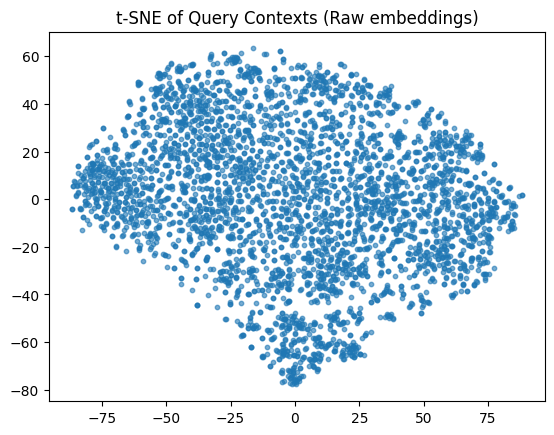

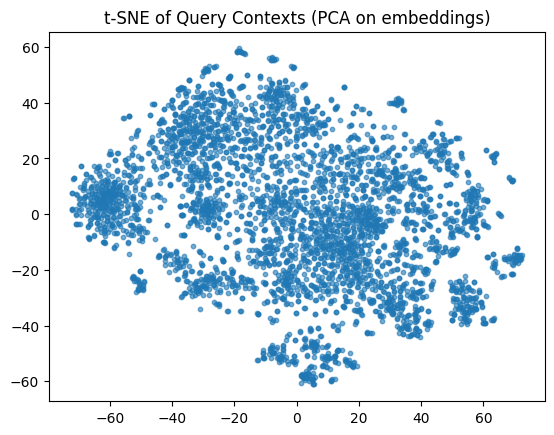

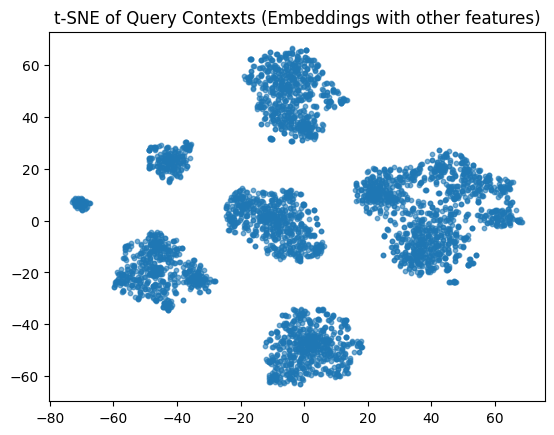

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


tsne = TSNE(n_components=2)
raw_contexts = query_embeddings
proj = tsne.fit_transform(raw_contexts)
plt.scatter(proj[:,0], proj[:,1], s=10, alpha=0.6)
plt.title("t-SNE of Query Contexts (Raw embeddings)")
plt.show()

tsne = TSNE(n_components=2)
raw_contexts = query_embeddings_reduced
proj = tsne.fit_transform(raw_contexts)
plt.scatter(proj[:,0], proj[:,1], s=10, alpha=0.6)
plt.title("t-SNE of Query Contexts (PCA on embeddings)")
plt.show()

#temp_contexts = [get_query_features(q, query_embeddings_reduced[i]) for i, q in enumerate(train_queries)]
#temp_contexts = np.vstack(contexts)
proj = tsne.fit_transform(contexts)
plt.scatter(proj[:,0], proj[:,1], s=10, alpha=0.6)
plt.title("t-SNE of Query Contexts (Embeddings with other features)")
plt.show()


# **PPO (Continuous actions)**

**Hyperparams**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical, Normal
from multiprocessing import Pool
from tqdm import tqdm
import numpy as np
import random
from sklearn.decomposition import PCA

# --- Toggle PCA ---
USE_PCA = False
PCA_DIM = 32  # adjust if needed

if USE_PCA:
    pca_ppo = PCA(n_components=PCA_DIM)
    pca_ppo.fit(query_embeddings)
    print(f"PCA applied: reduced from {query_embeddings[0].shape[0]} → {PCA_DIM} dimensions")
else:
    pca_ppo = None

# --- Hyperparameters ---
SET_SIZE = 256
CLIP_EPS = 0.2
PPO_EPOCHS = 5
NUM_UPDATES = 40
LR = 1e-4

TOP_K_VALUES = list(range(1, 11))

**PPO functions**

In [ ]:
def get_query_features_ppo(query, query_embedding):
    if USE_PCA:
        query_embedding = pca_ppo.transform(query_embedding.reshape(1, -1))[0]
    length = len(query.split())
    diversity  = len(set(query.lower().split())) / (length + 1e-5)
    first_word = query.strip().split()[0].lower() if query else ""
    type_flags = [1 if first_word == qtype else 0 for qtype in ["what", "who", "when", "where", "why", "how"]]
    return np.concatenate([query_embedding, [length / 10.0, diversity] + type_flags])

class RetrievalPolicy(nn.Module):
    def __init__(self, input_dim=392, hidden_dim=128):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.k_head = nn.Linear(hidden_dim, len(TOP_K_VALUES))
        self.lambda_mu = nn.Linear(hidden_dim, 1)
        self.lambda_logstd = nn.Linear(hidden_dim, 1)
        self.tau_mu = nn.Linear(hidden_dim, 1)
        self.tau_logstd = nn.Linear(hidden_dim, 1)

    def forward(self, context_tensor):
        h = self.fc(context_tensor)
        logits_k = self.k_head(h)
        lambda_mu = torch.sigmoid(self.lambda_mu(h))
        lambda_std = F.softplus(self.lambda_logstd(h))
        tau_mu = torch.sigmoid(self.tau_mu(h))
        tau_std = F.softplus(self.tau_logstd(h))
        return logits_k, lambda_mu, lambda_std, tau_mu, tau_std

def sample_action(policy, context_tensor):
    logits_k, lambda_mu, lambda_std, tau_mu, tau_std = policy(context_tensor)
    k_dist = Categorical(logits=logits_k)
    k_idx = k_dist.sample()
    top_k = TOP_K_VALUES[k_idx.item()]
    lambda_val = Normal(lambda_mu, lambda_std).sample().clamp(0, 1).item()
    tau_val = Normal(tau_mu, tau_std).sample().clamp(0.5, 0.8).item()
    log_prob_k = k_dist.log_prob(k_idx)
    return (top_k, lambda_val, tau_val), log_prob_k


def evaluate_single_query(args):
    query, query_embedding, (top_k, lambda_val, tau_val), context_np, log_prob = args
    if USE_PCA:
        query_embedding = pca_ppo.transform(query_embedding.reshape(1, -1))[0]
        doc_reduced = pca_ppo.transform(doc_embeddings)
    else:
        doc_reduced = doc_embeddings

    reward, score, token_cost = evaluate_retrieval(
        query=query,
        top_k=top_k,
        lambda_weight=lambda_val,
        tau=tau_val,
        query_embedding=query_embedding,
        doc_embeddings=doc_reduced,
        doc_idx_map=doc_idx_map
    )
    return context_np, (top_k, lambda_val, tau_val), reward, score, log_prob, token_cost

def collect_batch(policy, train_queries, query_embeddings, num_workers=8):
    args = []
    for i, query in enumerate(train_queries):
        emb = query_embeddings[i]
        context_np = get_query_features(query, emb)
        context_tensor = torch.tensor(context_np, dtype=torch.float32).unsqueeze(0).detach()
        (top_k, lambda_val, tau_val), log_prob = sample_action(policy, context_tensor)
        args.append((query, emb, (top_k, lambda_val, tau_val), context_np, log_prob.item()))

    with Pool(num_workers) as pool:
        results = list(tqdm(pool.imap(evaluate_single_query, args), total=len(args)))

    contexts = [torch.tensor(r[0], dtype=torch.float32) for r in results]
    actions  = [r[1] for r in results]
    rewards  = [r[2] for r in results]
    scores   = [r[3] for r in results]
    log_probs  = [r[4] for r in results]
    token_cost  = [r[5] for r in results]

    return contexts, actions, log_probs, rewards, scores, token_cost

def evaluate_policy_on_validation(policy, val_queries, val_embeddings):
    policy.eval()
    rewards = []
    with torch.no_grad():
        for query, emb in zip(val_queries, val_embeddings):
            context_np = get_query_features_ppo(query, emb)
            context_tensor = torch.tensor(context_np, dtype=torch.float32).unsqueeze(0)

            logits_k, lambda_mu, _, tau_mu, _ = policy(context_tensor)
            top_k = TOP_K_VALUES[torch.argmax(logits_k, dim=-1).item()]
            lambda_val = lambda_mu.item()
            tau_val = tau_mu.item()

            reward, _, token_cost = evaluate_retrieval(
                query=query,
                top_k=top_k,
                lambda_weight=lambda_val,
                tau=tau_val,
                query_embedding=emb,
                doc_embeddings=doc_embeddings,
                doc_idx_map=doc_idx_map
            )
            rewards.append(reward)
    return np.mean(rewards)

def run_ppo_evaluation(test_queries, test_query_embeddings, policy, batch_size=64):
    policy.eval()
    actions = []
    rewards = []
    scores = []
    samples = []
    token_costs = []

    ppo_results = []

    with torch.no_grad():
        for batch_start in tqdm(range(0, len(test_queries), batch_size), desc="Evaluating PPO"):
            batch_end = batch_start + batch_size
            batch_queries = test_queries[batch_start:batch_end]
            batch_embeddings = test_query_embeddings[batch_start:batch_end]

            context_list = [get_query_features_ppo(q, emb) for q, emb in zip(batch_queries, batch_embeddings)]
            context_tensor = torch.tensor(context_list, dtype=torch.float32)

            # Greedy inference
            logits_k, lambda_mu, _, tau_mu, _ = policy(context_tensor)
            k_idx = torch.argmax(logits_k, dim=-1)  # greedy top_k
            top_ks = [TOP_K_VALUES[i.item()] for i in k_idx]

            lambda_vals = lambda_mu.squeeze().tolist()  # mean value
            tau_vals = tau_mu.squeeze().tolist()

            for i in range(len(batch_queries)):
                reward, score, token_cost = evaluate_retrieval(
                    query=batch_queries[i],
                    top_k=top_ks[i],
                    lambda_weight=lambda_vals[i],
                    tau=tau_vals[i],
                    query_embedding=batch_embeddings[i],
                    doc_embeddings=doc_embeddings,
                    doc_idx_map=doc_idx_map
                )

                actions.append((top_ks[i], lambda_vals[i], tau_vals[i]))
                rewards.append(reward)
                scores.append(score)
                token_costs.append(token_cost)

                if len(samples) < 5:
                    samples.append((batch_queries[i], top_ks[i], lambda_vals[i], tau_vals[i], reward))

                ppo_results.append({
                    "agent": "PPO",
                    "query": batch_queries[i],
                    "top_k": top_ks[i],
                    "lambda": lambda_vals[i],
                    "tau": tau_vals[i],
                    "reward": reward,
                    "score": score,
                    "cost": token_cost,
                    "length": len(batch_queries[i].split()),  # Query length
                    "diversity": len(set(batch_queries[i].lower().split())) / (len(batch_queries[i].split()) + 1e-5),
                    "qtype": batch_queries[i].split()[0].lower()  # First word (e.g., what, when, where, etc.)
                })

    print("=== PPO Sample Predictions ===")
    for i, (query, k, lam, tau, reward) in enumerate(samples, 1):
        print(f"{i}. Query: {query}")
        print(f"   Action → top_k={k}, lambda={lam:.2f}, tau={tau:.2f}, Reward={reward:.4f}\n")

    print("=== PPO Evaluation Summary ===")
    print(f"→ Avg. Reward: {np.mean(rewards):.4f}")
    print(f"→ Avg. Relevance Score: {np.mean(scores):.4f}")
    print(f"→ Avg. Token costs: {np.mean(token_costs):.4f}")

    return np.mean(rewards), np.mean(scores), rewards, actions, token_costs, ppo_results


In [ ]:
# === Initialize PPO ===
dummy_context = get_query_features_ppo(train_queries[0], query_embeddings[0])
input_dim = len(dummy_context)
policy = RetrievalPolicy(input_dim=input_dim)
optimizer = torch.optim.Adam(policy.parameters(), lr=LR)
#initial_weight = 0.05

# storage
ppo_rewards_pre  = []
ppo_rewards_post = []
ppo_results      = []
ppo_rewards_per_update = []


In [ ]:
import random
import numpy as np
import torch
from torch.distributions import Categorical, Normal

# === Hyper-params for clipped PPO ===
EPS_CLIP     = 0.2     # clip ε in [1–ε, 1+ε]
ENTROPY_COEF = 0.01    # weight on entropy bonus

# helper: compute new log-probs *and* batch entropy
def compute_log_probs_and_entropy(policy, contexts_t, actions):
    """
    contexts_t: Tensor [B, D]
    actions:    list of B tuples (top_k, lambda_val, tau_val)
    Returns:
      log_probs: Tensor [B]
      entropy:   scalar Tensor
    """
    # forward pass
    logits_k, lam_mu, lam_std, tau_mu, tau_std = policy(contexts_t)

    # build dists
    dist_k   = Categorical(logits=logits_k)
    dist_lam = Normal(lam_mu, lam_std)
    dist_tau = Normal(tau_mu, tau_std)

    # index / value tensors for the same actions
    k_idxs = torch.tensor(
        [TOP_K_VALUES.index(a[0]) for a in actions],
        dtype=torch.long, device=contexts_t.device
    )
    lam_vals = torch.tensor(
        [a[1] for a in actions],
        dtype=torch.float32, device=contexts_t.device
    ).unsqueeze(-1)
    tau_vals = torch.tensor(
        [a[2] for a in actions],
        dtype=torch.float32, device=contexts_t.device
    ).unsqueeze(-1)

    # log-probs
    lp_k   = dist_k.log_prob(k_idxs)
    lp_lam = dist_lam.log_prob(lam_vals).squeeze(-1)
    lp_tau = dist_tau.log_prob(tau_vals).squeeze(-1)
    log_probs = lp_k + lp_lam + lp_tau

    # entropy bonus
    ent = (
        dist_k.entropy() +
        dist_lam.entropy().squeeze(-1) +
        dist_tau.entropy().squeeze(-1)
    )
    entropy = ent.mean()

    return log_probs, entropy


# === PPO Training Loop (improved) ===
for update in range(NUM_UPDATES):
    print(f"\n=== PPO Iteration {update+1} ===")

    # sample & collect
    idxs = random.sample(range(len(train_queries)), SET_SIZE)
    bq   = [train_queries[i]    for i in idxs]
    be   = [query_embeddings[i] for i in idxs]
    ctxs, acts, lp_old, rews, scores, token_cost = collect_batch(policy, bq, be)
    ctxs_t   = torch.stack(ctxs)                       # [B, D]
    lp_old_t = torch.tensor(lp_old, dtype=torch.float32, device=ctxs_t.device)
    rews_t   = torch.tensor(rews,   dtype=torch.float32, device=ctxs_t.device)

    # compute & normalize advantages
    baseline   = rews_t.mean()
    advantages = rews_t - baseline
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    # record before-update performance
    ppo_rewards_pre.append(baseline.item())

    # PPO epochs
    for epoch in range(PPO_EPOCHS):
        lp_new, entropy = compute_log_probs_and_entropy(policy, ctxs_t, acts)
        ratio = torch.exp(lp_new - lp_old_t)

        # clipped surrogate objective
        unclipped = ratio * advantages
        clipped   = torch.clamp(ratio, 1-EPS_CLIP, 1+EPS_CLIP) * advantages
        clip_loss = torch.min(unclipped, clipped).mean()

        # full loss = –surrogate + entropy bonus
        loss = -clip_loss - ENTROPY_COEF * entropy

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"[Epoch {epoch+1}] Loss: {loss.item():.4f}  Entropy: {entropy.item():.4f}")

    # post-update eval on the same batch
    with torch.no_grad():
        _, _, new_rews, _, _, _ = run_ppo_evaluation(bq, be, policy, batch_size=len(bq))
    ppo_rewards_post.append(np.mean(new_rews))

    # log detailed stats
    ppo_results.append({
        "iteration":  update+1,
        "pre_reward": baseline.item(),
        "post_reward": float(np.mean(new_rews)),
        "avg_score":   float(np.mean(scores)),
        #"avg_cost":   float(np.mean(token_costs)),
    })



=== PPO Iteration 1 ===


100%|██████████| 256/256 [00:05<00:00, 42.70it/s]


[Epoch 1] Loss: 0.0847  Entropy: 4.4670
[Epoch 2] Loss: 0.0845  Entropy: 4.4647
[Epoch 3] Loss: 0.0844  Entropy: 4.4625
[Epoch 4] Loss: 0.0843  Entropy: 4.4602
[Epoch 5] Loss: 0.0842  Entropy: 4.4579


Evaluating PPO: 100%|██████████| 1/1 [00:05<00:00,  5.18s/it]


=== PPO Sample Predictions ===
1. Query: why were british troops stationed in the colonies
   Action → top_k=4, lambda=0.50, tau=0.49, Reward=0.9250

2. Query: when did 8 out of 10 cats does countdown start
   Action → top_k=4, lambda=0.50, tau=0.49, Reward=0.9261

3. Query: how did jim propose to pam on the office
   Action → top_k=1, lambda=0.50, tau=0.49, Reward=0.9571

4. Query: who became ceo of it company vipro in 2016
   Action → top_k=4, lambda=0.50, tau=0.49, Reward=0.9696

5. Query: where were the bee gees born and raised
   Action → top_k=4, lambda=0.50, tau=0.49, Reward=0.9431

=== PPO Evaluation Summary ===
→ Avg. Reward: 0.8327
→ Avg. Relevance Score: 0.9023
→ Avg. Token costs: 107.5898

=== PPO Iteration 2 ===


...

=== PPO Sample Predictions ===
1. Query: where did they film the best exotic marigold hotel
   Action → top_k=9, lambda=0.35, tau=0.61, Reward=0.9591

2. Query: who set up the deseret community in utah
   Action → top_k=9, lambda=0.37, tau=0.59, Reward=0.9546

3. Query: what types of energy is used in australia
   Action → top_k=9, lambda=0.39, tau=0.58, Reward=0.9540

4. Query: who played mrs wolowitz on the big bang theory
   Action → top_k=9, lambda=0.36, tau=0.60, Reward=0.9267

5. Query: what is the type of government in norway
   Action → top_k=9, lambda=0.39, tau=0.58, Reward=0.9266

=== PPO Evaluation Summary ===
→ Avg. Reward: 0.9208
→ Avg. Relevance Score: 0.9883
→ Avg. Token costs: 113.5586

=== PPO Iteration 40 ===


100%|██████████| 256/256 [00:05<00:00, 43.83it/s]


[Epoch 1] Loss: -0.0105  Entropy: 3.0496
[Epoch 2] Loss: -0.0113  Entropy: 3.0459
[Epoch 3] Loss: -0.0126  Entropy: 3.0444
[Epoch 4] Loss: -0.0142  Entropy: 3.0449
[Epoch 5] Loss: -0.0160  Entropy: 3.0470


Evaluating PPO: 100%|██████████| 1/1 [00:05<00:00,  5.37s/it]

=== PPO Sample Predictions ===
1. Query: where is the tv show southern charm filmed
   Action → top_k=9, lambda=0.34, tau=0.62, Reward=0.9578

2. Query: what is the action center in windows 10
   Action → top_k=9, lambda=0.38, tau=0.59, Reward=0.9044

3. Query: who is the author of the story how my brother leon brought home a wife
   Action → top_k=9, lambda=0.36, tau=0.60, Reward=0.9657

4. Query: when was the american museum of natural history built
   Action → top_k=9, lambda=0.37, tau=0.59, Reward=0.9582

5. Query: who organized a new political movement known as facism in 1919
   Action → top_k=9, lambda=0.37, tau=0.59, Reward=0.9587

=== PPO Evaluation Summary ===
→ Avg. Reward: 0.9197
→ Avg. Relevance Score: 0.9844
→ Avg. Token costs: 108.0664


# **Old PPO training loop (Ignore)**

In [ ]:
# # === PPO Training Loop ===
# for update in range(NUM_UPDATES):
#     print(f"\n=== PPO Iteration {update + 1} ===")
#     sampled_indices = random.sample(range(len(train_queries)), SET_SIZE)
#     batch_queries = [train_queries[i] for i in sampled_indices]
#     batch_embeddings = [query_embeddings[i] for i in sampled_indices]

#     contexts, actions, log_probs_old, rewards, scores = collect_batch(policy, batch_queries, batch_embeddings)
#     contexts_tensor = torch.stack(contexts)
#     log_probs_old_tensor = torch.tensor(log_probs_old, dtype=torch.float32)
#     rewards_tensor = torch.tensor(rewards, dtype=torch.float32)
#     baseline = rewards_tensor.mean()
#     advantages = rewards_tensor - baseline

#     # Record the batch's avg reward BEFORE optimization
#     avg_reward = rewards_tensor.mean().item()
#     ppo_rewards_per_update.append(avg_reward)

#     for epoch in range(PPO_EPOCHS):
#         logits_k, lambda_mu, lambda_std, tau_mu, tau_std = policy(contexts_tensor)

#         entropy_k = Categorical(logits=logits_k).entropy()
#         entropy_lambda = Normal(lambda_mu, lambda_std).entropy().squeeze()
#         entropy_tau = Normal(tau_mu, tau_std).entropy().squeeze()
#         '''log_probs_new = []
#         for i, action in enumerate(actions):
#             top_k, lambda_val, tau_val = action
#             k_idx = torch.tensor(TOP_K_VALUES.index(top_k)).to(contexts_tensor.device)
#             log_prob_k = Categorical(logits=logits_k[i]).log_prob(k_idx)
#             log_prob_lambda = Normal(lambda_mu[i], lambda_std[i]).log_prob(torch.tensor(lambda_val)).squeeze()
#             log_prob_tau = Normal(tau_mu[i], tau_std[i]).log_prob(torch.tensor(tau_val)).squeeze()
#             log_probs_new.append(log_prob_k + log_prob_lambda + log_prob_tau)

#         log_probs_new_tensor = torch.stack(log_probs_new)'''
#         # Vectorized top_k log-prob
#         k_indices = torch.tensor([TOP_K_VALUES.index(a[0]) for a in actions]).to(contexts_tensor.device)
#         log_probs_k = Categorical(logits=logits_k).log_prob(k_indices)

#         # Vectorized lambda and tau log-probs
#         log_probs_lambda = torch.stack([
#             Normal(lambda_mu[i], lambda_std[i]).log_prob(torch.tensor(a[1])).squeeze()
#             for i, a in enumerate(actions)
#         ])

#         log_probs_tau = torch.stack([
#             Normal(tau_mu[i], tau_std[i]).log_prob(torch.tensor(a[2])).squeeze()
#             for i, a in enumerate(actions)
#         ])

#         # Combine all log-probs
#         log_probs_new_tensor = log_probs_k + log_probs_lambda + log_probs_tau

#         ratios = torch.exp(log_probs_new_tensor - log_probs_old_tensor)
#         clip_loss = torch.min(ratios * advantages, torch.clamp(ratios, 1 - CLIP_EPS, 1 + CLIP_EPS) * advantages)
#         entropy = entropy_k.mean() + entropy_lambda.mean() + entropy_tau.mean()

#         #entropy_weight = initial_weight * (1 - update / NUM_UPDATES)
#         #loss = -clip_loss.mean() - entropy_weight * entropy
#         loss = -clip_loss.mean() - 0.01 * entropy

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         #print("logits_k (first 5):", logits_k[:5].detach().cpu().numpy())

#         print(f"[Epoch {epoch + 1}] PPO Loss: {loss.item():.4f}")
#         print(f"  → Entropy_k: {entropy_k.mean().item():.2f}, lambda: {entropy_lambda.mean().item():.2f}, tau: {entropy_tau.mean().item():.2f}")

#     print(f"→ Avg. Reward: {rewards_tensor.mean():.4f}")
#     print(f"→ Avg. Relevance Score: {np.mean(scores):.4f}")
#     #val_reward = evaluate_policy_on_validation(policy, val_queries, val_embeddings) # Run validatoin on a separate set
#     #ppo_rewards_per_update.append(val_reward)
#     #print(f"→ Val Reward: {val_reward:.4f}")

#     # === Logging per query (match order in batch_queries) ===
#     for i, query in enumerate(batch_queries):
#         top_k, lambda_val, tau_val = actions[i]
#         reward = rewards[i]
#         relevance_score = scores[i]

#         # Recompute context features
#         query_embedding = batch_embeddings[i]
#         query_features = get_query_features(query, query_embedding)
#         length = query_features[-8]
#         entropy_val = query_features[-7]
#         qtype = query.strip().split()[0].lower() if query else "unknown"

#         # Estimate cost from evaluate_retrieval if needed
#         filtered_docs = hybrid_retrieve(query, top_k, lambda_val,
#                                         query_embedding=query_embedding,
#                                         doc_embeddings=doc_embeddings,
#                                         doc_idx_map=doc_idx_map)
#         token_cost = sum(len(doc.split()) for doc in filtered_docs)

#       #  ppo_results.append({
#       #       "agent": "PPO",
#       #       "query": query,
#       #       "top_k": top_k,
#       #       "lambda": lambda_val,
#       #       "tau": tau_val,
#       #       "reward": reward,
#       #       "score": relevance_score,
#       #       "cost": token_cost,
#       #       "length": length,
#       #       "entropy": entropy_val,
#       #       "qtype": qtype
#       #   })





=== PPO Iteration 1 ===


100%|██████████| 256/256 [00:06<00:00, 40.19it/s]


[Epoch 1] PPO Loss: 0.0712
  → Entropy_k: 2.30, lambda: 1.16, tau: 1.07
[Epoch 2] PPO Loss: 0.0710
  → Entropy_k: 2.30, lambda: 1.16, tau: 1.07
[Epoch 3] PPO Loss: 0.0709
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.07
[Epoch 4] PPO Loss: 0.0708
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.06
[Epoch 5] PPO Loss: 0.0707
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.06
→ Avg. Reward: 0.6450
→ Avg. Relevance Score: 0.6758

=== PPO Iteration 2 ===


100%|██████████| 256/256 [00:05<00:00, 43.07it/s]


[Epoch 1] PPO Loss: 0.0753
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.06
[Epoch 2] PPO Loss: 0.0752
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.06
[Epoch 3] PPO Loss: 0.0751
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.06
[Epoch 4] PPO Loss: 0.0750
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.05
[Epoch 5] PPO Loss: 0.0749
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.05
→ Avg. Reward: 0.6233
→ Avg. Relevance Score: 0.6523

=== PPO Iteration 3 ===


...

[Epoch 1] PPO Loss: -0.0117
  → Entropy_k: 2.29, lambda: 0.74, tau: 0.24
[Epoch 2] PPO Loss: -0.0130
  → Entropy_k: 2.29, lambda: 0.73, tau: 0.22
[Epoch 3] PPO Loss: -0.0142
  → Entropy_k: 2.29, lambda: 0.72, tau: 0.20
[Epoch 4] PPO Loss: -0.0153
  → Entropy_k: 2.29, lambda: 0.71, tau: 0.19
[Epoch 5] PPO Loss: -0.0163
  → Entropy_k: 2.29, lambda: 0.71, tau: 0.17
→ Avg. Reward: 0.6251
→ Avg. Relevance Score: 0.6523

=== PPO Iteration 29 ===


100%|██████████| 256/256 [00:05<00:00, 44.14it/s]


[Epoch 1] PPO Loss: -0.0162
  → Entropy_k: 2.29, lambda: 0.70, tau: 0.15
[Epoch 2] PPO Loss: -0.0167
  → Entropy_k: 2.29, lambda: 0.69, tau: 0.13
[Epoch 3] PPO Loss: -0.0173
  → Entropy_k: 2.29, lambda: 0.69, tau: 0.12
[Epoch 4] PPO Loss: -0.0178
  → Entropy_k: 2.29, lambda: 0.68, tau: 0.10
[Epoch 5] PPO Loss: -0.0185
  → Entropy_k: 2.29, lambda: 0.68, tau: 0.09
→ Avg. Reward: 0.6430
→ Avg. Relevance Score: 0.6719

=== PPO Iteration 30 ===


100%|██████████| 256/256 [00:05<00:00, 43.85it/s]


[Epoch 1] PPO Loss: -0.0260
  → Entropy_k: 2.29, lambda: 0.68, tau: 0.08
[Epoch 2] PPO Loss: -0.0259
  → Entropy_k: 2.29, lambda: 0.68, tau: 0.07
[Epoch 3] PPO Loss: -0.0259
  → Entropy_k: 2.29, lambda: 0.68, tau: 0.06
[Epoch 4] PPO Loss: -0.0260
  → Entropy_k: 2.29, lambda: 0.68, tau: 0.05
[Epoch 5] PPO Loss: -0.0263
  → Entropy_k: 2.29, lambda: 0.68, tau: 0.04
→ Avg. Reward: 0.7023
→ Avg. Relevance Score: 0.7344


# **Plots**

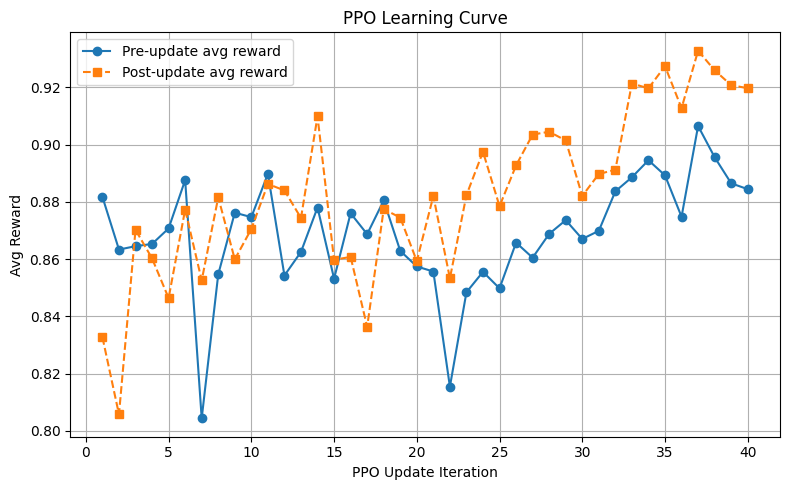

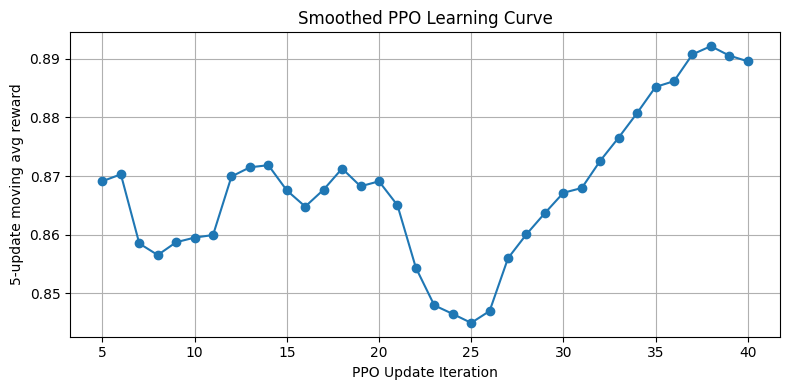

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1) PPO Learning Curve (pre‐ vs. post‐update) ---
updates = np.arange(1, len(ppo_rewards_pre) + 1)

plt.figure(figsize=(8, 5))
plt.plot(updates, ppo_rewards_pre,  marker='o', linestyle='-', label='Pre‐update avg reward')
plt.plot(updates, ppo_rewards_post, marker='s', linestyle='--', label='Post‐update avg reward')
plt.xlabel('PPO Update Iteration')
plt.ylabel('Avg Reward')
plt.title('PPO Learning Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# (Optional) Smoothing
def moving_average(x, window=5):
    return np.convolve(x, np.ones(window)/window, mode='valid')

window = 5
smoothed = moving_average(ppo_rewards_pre, window)
plt.figure(figsize=(8, 4))
plt.plot(np.arange(window, len(ppo_rewards_pre)+1), smoothed, marker='o')
plt.xlabel('PPO Update Iteration')
plt.ylabel(f'{window}-update moving avg reward')
plt.title('Smoothed PPO Learning Curve')
plt.grid(True)
plt.tight_layout()
plt.show()


# # --- 2) Reward Distribution Across Methods ---
# # Make sure you’ve already populated these via:
# #   mab_avg, _, mab_rewards, _    = run_noncontextual_mab_evaluation(...)
# #   cmab_avg, _, cmab_rewards, _  = run_cmab_evaluation(...)
# #   ppo_avg, _, ppo_rewards, _    = run_ppo_evaluation(...)
# data   = [mab_rewards, cmab_rewards, ppo_rewards]
# labels = ['Non-Contextual MAB', 'Contextual MAB', 'PPO']

# plt.figure(figsize=(8, 6))
# plt.boxplot(data, labels=labels)
# plt.title('Reward Distribution Across Methods')
# plt.ylabel('Reward')
# plt.grid(True, axis='y')
# plt.tight_layout()
# # make y lable more concise
# plt.ylim(0.9, 1.0)
# plt.show()


# **A2C**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical, Normal

TOP_K_VALUES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

class RetrievalActorCritic(nn.Module):
    def __init__(self, input_dim=392, hidden_dim=128):
        super().__init__()
        # Shared backbone
        self.fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        # Actor heads
        self.k_head = nn.Linear(hidden_dim, len(TOP_K_VALUES))
        self.lambda_mu = nn.Linear(hidden_dim, 1)
        self.lambda_logstd = nn.Linear(hidden_dim, 1)
        self.tau_mu = nn.Linear(hidden_dim, 1)
        self.tau_logstd = nn.Linear(hidden_dim, 1)

        # Critic head
        self.value_head = nn.Linear(hidden_dim, 1)

    def forward(self, context_tensor):
        h = self.fc(context_tensor)
        # Actor outputs
        logits_k = self.k_head(h)
        lambda_mu = torch.sigmoid(self.lambda_mu(h))
        lambda_std = F.softplus(self.lambda_logstd(h))
        tau_mu = torch.sigmoid(self.tau_mu(h))
        tau_std = F.softplus(self.tau_logstd(h))
        # Critic output
        value = self.value_head(h)
        return logits_k, lambda_mu, lambda_std, tau_mu, tau_std, value


In [ ]:
# Initialize
model = RetrievalActorCritic(input_dim=len(get_query_features(train_queries[0], query_embeddings[0])))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Hyperparameters
SET_SIZE = 256
NUM_UPDATES = 30

# A2C Loop
for update in range(NUM_UPDATES):
    print(f"\n=== A2C Iteration {update + 1} ===")

    sampled_indices = random.sample(range(len(train_queries)), SET_SIZE)
    batch_queries = [train_queries[i] for i in sampled_indices]
    batch_embeddings = [query_embeddings[i] for i in sampled_indices]

    contexts = [get_query_features(q, emb) for q, emb in zip(batch_queries, batch_embeddings)]
    context_tensor = torch.tensor(contexts, dtype=torch.float32)

    logits_k, lambda_mu, lambda_std, tau_mu, tau_std, values = model(context_tensor)

    actions = []
    log_probs = []
    rewards = []
    entropies = []

    for i in range(len(batch_queries)):
        # Sample actions
        k_dist = Categorical(logits=logits_k[i])
        k_idx = k_dist.sample()
        top_k = TOP_K_VALUES[k_idx.item()]
        lambda_val = Normal(lambda_mu[i], lambda_std[i]).sample().clamp(0, 1).item()
        tau_val = Normal(tau_mu[i], tau_std[i]).sample().clamp(0.5, 0.8).item()

        # Log-prob
        log_prob = k_dist.log_prob(k_idx) \
                 + Normal(lambda_mu[i], lambda_std[i]).log_prob(torch.tensor(lambda_val)).squeeze() \
                 + Normal(tau_mu[i], tau_std[i]).log_prob(torch.tensor(tau_val)).squeeze()

        # Entropy
        entropy = k_dist.entropy() + Normal(lambda_mu[i], lambda_std[i]).entropy().squeeze() + Normal(tau_mu[i], tau_std[i]).entropy().squeeze()

        # Evaluate action
        reward, _, token_cost = evaluate_retrieval(
            query=batch_queries[i],
            top_k=top_k,
            lambda_weight=lambda_val,
            tau=tau_val,
            query_embedding=batch_embeddings[i],
            doc_embeddings=doc_embeddings,
            doc_idx_map=doc_idx_map
        )

        actions.append((top_k, lambda_val, tau_val))
        log_probs.append(log_prob)
        rewards.append(reward)
        entropies.append(entropy)

    # Prepare tensors
    log_probs_tensor = torch.stack(log_probs)
    rewards_tensor = torch.tensor(rewards, dtype=torch.float32)
    values_tensor = values.squeeze()

    # Advantage
    #advantages = rewards_tensor - values_tensor.detach()
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    # A2C Loss
    actor_loss = -(log_probs_tensor * advantages).mean()
    critic_loss = F.mse_loss(values_tensor, rewards_tensor)
    entropy_bonus = torch.stack(entropies).mean()

    total_loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy_bonus

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    print(f"Total Loss: {total_loss.item():.4f} | Actor: {actor_loss.item():.4f} | Critic: {critic_loss.item():.4f} | Entropy: {entropy_bonus.item():.2f}")



=== A2C Iteration 1 ===
Total Loss: 0.2757 | Actor: 0.0054 | Critic: 0.6273 | Entropy: 4.34

=== A2C Iteration 2 ===
Total Loss: 0.2788 | Actor: 0.0041 | Critic: 0.6362 | Entropy: 4.34

=== A2C Iteration 3 ===
Total Loss: 0.2607 | Actor: 0.0005 | Critic: 0.6071 | Entropy: 4.34

=== A2C Iteration 4 ===
Total Loss: 0.2456 | Actor: -0.0123 | Critic: 0.6025 | Entropy: 4.34

=== A2C Iteration 5 ===
Total Loss: 0.2705 | Actor: 0.0083 | Critic: 0.6111 | Entropy: 4.34

=== A2C Iteration 6 ===
Total Loss: 0.2664 | Actor: 0.0107 | Critic: 0.5980 | Entropy: 4.34

=== A2C Iteration 7 ===
Total Loss: 0.2598 | Actor: 0.0074 | Critic: 0.5913 | Entropy: 4.34

=== A2C Iteration 8 ===
Total Loss: 0.2509 | Actor: -0.0112 | Critic: 0.6110 | Entropy: 4.34

=== A2C Iteration 9 ===
Total Loss: 0.2698 | Actor: 0.0084 | Critic: 0.6094 | Entropy: 4.34

=== A2C Iteration 10 ===
Total Loss: 0.2593 | Actor: -0.0023 | Critic: 0.6098 | Entropy: 4.34

=== A2C Iteration 11 ===
Total Loss: 0.2423 | Actor: 0.0043 | Cri

# **Evaluation**

In [ ]:
test_queries = random.sample(questions, TEST_SIZE)

print("Encoding test queries (batched)...")
test_query_embeddings = []

for i in tqdm(range(0, len(test_queries), encode_batch_size), desc="Test Queries"):
    batch = test_queries[i:i+encode_batch_size]
    embs = dense_model.encode(batch, normalize_embeddings=True)
    test_query_embeddings.append(embs)

test_query_embeddings = np.vstack(test_query_embeddings)


Encoding test queries (batched)...


Test Queries: 100%|██████████| 10/10 [00:00<00:00, 81.65it/s]


# **Non-Contextual MAB Test**

In [ ]:
from collections import Counter

def run_noncontextual_mab_evaluation(test_queries, mab_model, action_map):
    rewards = []
    scores = []
    actions = []
    samples = []
    token_costs= []

    for query in test_queries:
        action_id = mab_model.predict()
        top_k, lambda_val, tau_val = action_map[action_id]

        reward, score, token_cost = evaluate_retrieval(
            query,
            top_k=top_k,
            lambda_weight=lambda_val,
            tau=tau_val,
            query_embedding=None,  # non-contextual retrieval
            doc_embeddings=doc_embeddings,
            doc_idx_map=doc_idx_map
        )

        rewards.append(reward)
        scores.append(score)
        actions.append(action_id)
        token_costs.append(token_cost)

        if len(samples) < 5:
            samples.append((query, top_k, lambda_val, tau_val, reward, token_cost))

    avg_reward = np.mean(rewards)
    avg_score = np.mean(scores)
    action_distribution = Counter(actions)
    avg_cost = np.mean(token_costs)

    # Display Results
    print("=== Non-Contextual MAB Sample Predictions ===")
    for i, (query, k, lam, tau, reward, token_cost) in enumerate(samples, 1):
        print(f"{i}. Query: {query}")
        print(f"   Selected Action: top_k={k}, lambda={lam:.2f}, tau={tau:.2f}, Reward={reward:.4f}, token costs={token_cost}\n")

    print("=== Non-Contextual MAB Evaluation Summary ===")
    print(f"→ Avg. Reward: {avg_reward:.4f}")
    print(f"→ Avg. Relevance Score: {avg_score:.4f}")
    print(f"→ Avg. Token cost: {avg_cost:.4f}")
    print("→ Action Distribution:")
    for action_id, count in action_distribution.items():
        k, lam, tau = action_map[action_id]
        print(f"  Index {action_id} → top_k={k}, lambda={lam}, tau={tau} (count={count})")

    return avg_reward, avg_score, rewards, actions, token_costs

mab_reward, mab_score, mab_rewards, mab_actions, mab_token_costs = run_noncontextual_mab_evaluation(
    test_queries,
    mab_model=mab,
    action_map=action_map
)

=== Non-Contextual MAB Sample Predictions ===
1. Query: where is the red marking on a black widow
   Selected Action: top_k=3, lambda=0.70, tau=0.80, Reward=0.0000, token costs=0

2. Query: where did the civilisation of ancient rome begin
   Selected Action: top_k=3, lambda=0.70, tau=0.80, Reward=0.9525, token costs=94

3. Query: where was return of a man called horse filmed
   Selected Action: top_k=5, lambda=1.00, tau=0.55, Reward=0.9710, token costs=32

4. Query: who won the womens singles at wimbledon 2018
   Selected Action: top_k=3, lambda=0.70, tau=0.80, Reward=0.9795, token costs=40

5. Query: when does the school year start in norway
   Selected Action: top_k=3, lambda=0.70, tau=0.80, Reward=0.9765, token costs=46

=== Non-Contextual MAB Evaluation Summary ===
→ Avg. Reward: 0.8531
→ Avg. Relevance Score: 0.9064
→ Avg. Token cost: 105.1733
→ Action Distribution:
  Index 209 → top_k=3, lambda=0.7, tau=0.8 (count=292)
  Index 379 → top_k=5, lambda=1, tau=0.55 (count=1)
  Index 3

# **Contextual MAB Test**

In [ ]:
from collections import Counter

def run_cmab_evaluation(test_queries, test_query_embeddings, cmab_model, action_map, pca=None):
    rewards = []
    scores = []
    actions = []
    samples = []
    token_costs= []

    for i, query in enumerate(test_queries):
        query_embedding = test_query_embeddings[i]

        # Apply PCA if provided
        if pca is not None:
            query_embedding = pca.transform([query_embedding])[0]

        context = get_query_features(query, query_embedding).reshape(1, -1)
        action_id = cmab_model.predict(context)
        top_k, lambda_val, tau_val = action_map[action_id]

        reward, score, token_cost = evaluate_retrieval(
            query=query,
            top_k=top_k,
            lambda_weight=lambda_val,
            tau=tau_val,
            query_embedding=test_query_embeddings[i],  # full dim for retrieval
            doc_embeddings=doc_embeddings,
            doc_idx_map=doc_idx_map
        )

        rewards.append(reward)
        scores.append(score)
        actions.append(action_id)
        token_costs.append(token_cost)

        if len(samples) < 5:
            samples.append((query, top_k, lambda_val, tau_val, reward, token_cost))

    avg_reward = np.mean(rewards)
    avg_score = np.mean(scores)
    avg_cost = np.mean(token_costs)
    action_distribution = Counter(actions)

    # Display Results
    print("=== Contextual MAB Sample Predictions ===")
    for i, (query, k, lam, tau, reward, token_cost) in enumerate(samples, 1):
        print(f"{i}. Query: {query}")
        print(f"   Selected Action: top_k={k}, lambda={lam:.2f}, tau={tau:.2f}, Reward={reward:.4f}, token cost={token_cost}\n")

    print("=== Contextual MAB Evaluation Summary ===")
    print(f"→ Avg. Reward: {avg_reward:.4f}")
    print(f"→ Avg. Relevance Score: {avg_score:.4f}")
    print(f"→ Avg. Token cost: {avg_cost:.4f}")
    print("→ Action Distribution:")
    for action_id, count in action_distribution.items():
        k, lam, tau = action_map[action_id]
        print(f"  Index {action_id} → top_k={k}, lambda={lam}, tau={tau} (count={count})")

    return avg_reward, avg_score, rewards, actions, token_costs

# Run CMAB Evaluation
cmab_reward, cmab_score, cmab_rewards, cmab_actions, cmab_token_costs  = run_cmab_evaluation(
    test_queries, test_query_embeddings,
    cmab_model=contextual_mab,
    action_map=action_map,
    pca=pca_cmab  # or None if not using PCA
)


=== Contextual MAB Sample Predictions ===
1. Query: where is the red marking on a black widow
   Selected Action: top_k=10, lambda=0.70, tau=0.65, Reward=0.9525, token cost=79

2. Query: where did the civilisation of ancient rome begin
   Selected Action: top_k=10, lambda=0.70, tau=0.65, Reward=0.9450, token cost=94

3. Query: where was return of a man called horse filmed
   Selected Action: top_k=10, lambda=0.70, tau=0.65, Reward=0.9760, token cost=32

4. Query: who won the womens singles at wimbledon 2018
   Selected Action: top_k=8, lambda=0.60, tau=0.80, Reward=0.9795, token cost=40

5. Query: when does the school year start in norway
   Selected Action: top_k=3, lambda=0.20, tau=0.70, Reward=0.9715, token cost=46

=== Contextual MAB Evaluation Summary ===
→ Avg. Reward: 0.9018
→ Avg. Relevance Score: 0.9667
→ Avg. Token cost: 115.1733
→ Action Distribution:
  Index 745 → top_k=10, lambda=0.7, tau=0.65 (count=83)
  Index 587 → top_k=8, lambda=0.6, tau=0.8 (count=14)
  Index 172 → t

# **PPO Test**

In [ ]:
from tqdm import tqdm


# Run PPO Evaluation
ppo_reward, ppo_score, ppo_rewards, ppo_actions, ppo_token_costs, ppo_test_results = run_ppo_evaluation(test_queries, test_query_embeddings, policy)

Evaluating PPO: 100%|██████████| 5/5 [00:05<00:00,  1.18s/it]

=== PPO Sample Predictions ===
1. Query: where is the red marking on a black widow
   Action → top_k=9, lambda=0.37, tau=0.59, Reward=0.9495

2. Query: where did the civilisation of ancient rome begin
   Action → top_k=9, lambda=0.36, tau=0.60, Reward=0.9426

3. Query: where was return of a man called horse filmed
   Action → top_k=9, lambda=0.34, tau=0.62, Reward=0.9743

4. Query: who won the womens singles at wimbledon 2018
   Action → top_k=9, lambda=0.40, tau=0.58, Reward=0.9684

5. Query: when does the school year start in norway
   Action → top_k=9, lambda=0.36, tau=0.60, Reward=0.9665

=== PPO Evaluation Summary ===
→ Avg. Reward: 0.9261
→ Avg. Relevance Score: 0.9967
→ Avg. Token costs: 119.9900


# **A2C Test**

In [ ]:
from tqdm import tqdm

def run_a2c_evaluation(test_queries, test_query_embeddings, model, batch_size=64):
    model.eval()
    actions = []
    rewards = []
    scores = []
    samples = []
    a2c_results = []
    token_costs = []

    with torch.no_grad():
        for batch_start in tqdm(range(0, len(test_queries), batch_size), desc="Evaluating A2C"):
            batch_end = batch_start + batch_size
            batch_queries = test_queries[batch_start:batch_end]
            batch_embeddings = test_query_embeddings[batch_start:batch_end]

            context_list = [get_query_features(q, emb) for q, emb in zip(batch_queries, batch_embeddings)]
            context_tensor = torch.tensor(context_list, dtype=torch.float32)

            # Greedy inference
            logits_k, lambda_mu, _, tau_mu, _, _ = model(context_tensor)
            k_idx = torch.argmax(logits_k, dim=-1)  # deterministic top_k choice
            top_ks = [TOP_K_VALUES[i.item()] for i in k_idx]

            lambda_vals = lambda_mu.squeeze().tolist()  # take mean
            tau_vals = tau_mu.squeeze().tolist()        # take mean

            for i in range(len(batch_queries)):
                reward, score, token_cost = evaluate_retrieval(
                    query=batch_queries[i],
                    top_k=top_ks[i],
                    lambda_weight=lambda_vals[i],
                    tau=tau_vals[i],
                    query_embedding=batch_embeddings[i],
                    doc_embeddings=doc_embeddings,
                    doc_idx_map=doc_idx_map
                )

                actions.append((top_ks[i], lambda_vals[i], tau_vals[i]))
                rewards.append(reward)
                scores.append(score)
                token_costs.append(token_cost)

                if len(samples) < 5:
                    samples.append((batch_queries[i], top_ks[i], lambda_vals[i], tau_vals[i], reward))


                a2c_results.append({
                    "agent": "A2C",
                    "query": batch_queries[i],
                    "top_k": top_ks[i],
                    "lambda": lambda_vals[i],
                    "tau": tau_vals[i],
                    "reward": reward,
                    "score": score,
                    "cost": token_cost,
                    "length": len(batch_queries[i].split()),  # Query length
                    "diversity": len(set(batch_queries[i].lower().split())) / (len(batch_queries[i].split()) + 1e-5),
                    "qtype": batch_queries[i].split()[0].lower()  # First word (e.g., what, when, where, etc.)
                })

    print("=== A2C Sample Predictions ===")
    for i, (query, k, lam, tau, reward) in enumerate(samples, 1):
        print(f"{i}. Query: {query}")
        print(f"   Action → top_k={k}, lambda={lam:.2f}, tau={tau:.2f}, Reward={reward:.4f}\n")


    print("=== A2C Evaluation Summary ===")
    print(f"→ Avg. Reward: {np.mean(rewards):.4f}")
    print(f"→ Avg. Relevance Score: {np.mean(scores):.4f}")
    print(f"→ Avg. Token cost: {np.mean(token_costs):.4f}")


    return np.mean(rewards), np.mean(scores), rewards, actions, a2c_results

# --- Run A2C Evaluation ---
a2c_reward, a2c_score, a2c_rewards, a2c_actions, a2c_test_results  = run_a2c_evaluation(test_queries, test_query_embeddings, model)


Evaluating A2C: 100%|██████████| 5/5 [00:05<00:00,  1.07s/it]

=== A2C Sample Predictions ===
1. Query: where is the red marking on a black widow
   Action → top_k=9, lambda=0.49, tau=0.50, Reward=0.9450

2. Query: where did the civilisation of ancient rome begin
   Action → top_k=9, lambda=0.49, tau=0.50, Reward=0.9374

3. Query: where was return of a man called horse filmed
   Action → top_k=9, lambda=0.49, tau=0.50, Reward=0.9683

4. Query: who won the womens singles at wimbledon 2018
   Action → top_k=9, lambda=0.49, tau=0.49, Reward=0.9642

5. Query: when does the school year start in norway
   Action → top_k=9, lambda=0.49, tau=0.50, Reward=0.9613

=== A2C Evaluation Summary ===
→ Avg. Reward: 0.9117
→ Avg. Relevance Score: 0.9867
→ Avg. Token cost: 118.5600


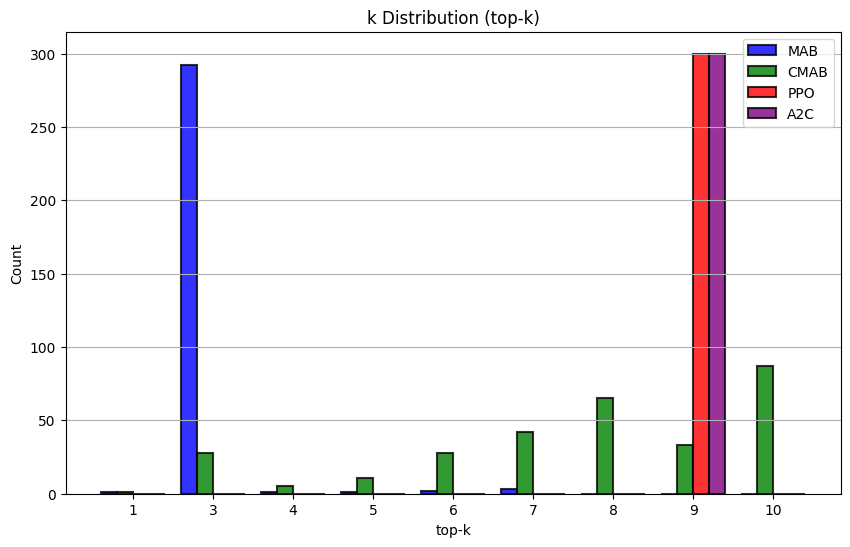

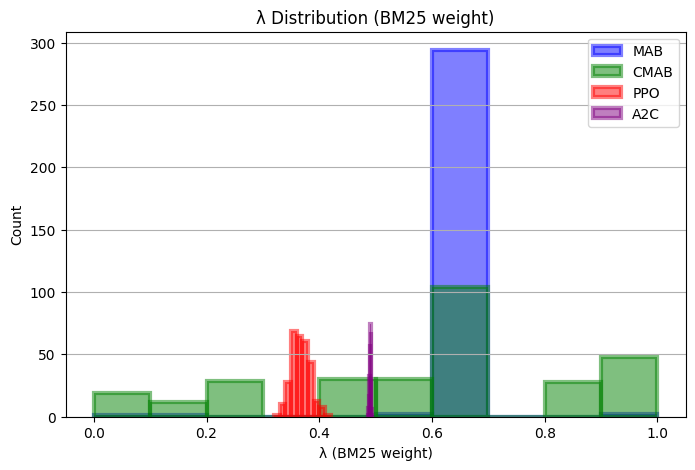

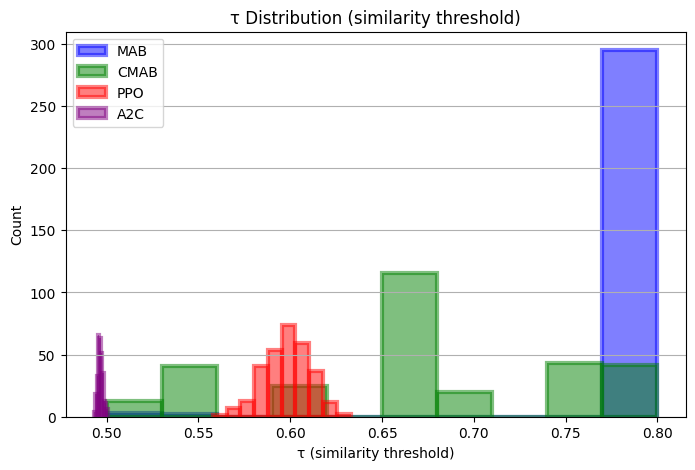

In [ ]:
import matplotlib.pyplot as plt


# Decode MAB and CMAB to (k, λ, τ)
mab_action_values = [action_map[idx] for idx in mab_actions]
cmab_action_values = [action_map[idx] for idx in cmab_actions]

# Separate each component
def unpack_components(actions):
    ks, lambdas, taus = zip(*actions)
    return ks, lambdas, taus

mab_k, mab_lambda, mab_tau = unpack_components(mab_action_values)
cmab_k, cmab_lambda, cmab_tau = unpack_components(cmab_action_values)
ppo_k, ppo_lambda, ppo_tau = unpack_components(ppo_actions)
a2c_k, a2c_lambda, a2c_tau = unpack_components(a2c_actions)

# Function to plot
def plot_k(distributions, labels, title, xlabel, colors=None):
    plt.figure(figsize=(10, 6))

    if colors is None:
        colors = ["blue", "green", "red", "purple"]

    # Get all unique k values
    unique_ks = sorted(set(k for dist in distributions for k in dist))

    x = np.arange(len(unique_ks))  # positions on x-axis
    width = 0.2  # width of each bar

    for i, (dist, label, color) in enumerate(zip(distributions, labels, colors)):
        # Count occurrences of each k
        counts = [dist.count(k) for k in unique_ks]
        plt.bar(
            x + i * width,         # Shift bars for each distribution
            counts,
            width=width,
            label=label,
            color=color,
            edgecolor="black",     # black outlines!
            linewidth=1.5,
            alpha=0.8
        )

    plt.xticks(x + width * (len(distributions) - 1) / 2, unique_ks)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True, axis='y')
    plt.show()

def plot_component(distributions, labels, bins, title, xlabel, colors=None):
    plt.figure(figsize=(8, 5))

    if colors is None:
        # Default colors if not provided
        colors = ["blue", "green", "red", "purple"]

    for dist, label, color in zip(distributions, labels, colors):
        plt.hist(
            dist,
            bins=bins,
            label=label,
            rwidth=1.5,
            histtype="bar",
            alpha=0.5,
            align='mid',
            color=color,          # fill color
            edgecolor=color,      # outline color (same as fill)
            linewidth=3         # add thick edge
        )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True, axis='y')
    plt.show()


# Now Plot Separately
plot_k(
    distributions=[mab_k, cmab_k, ppo_k, a2c_k],
    labels=["MAB", "CMAB", "PPO", "A2C"],
    title="k Distribution (top-k)",
    xlabel="top-k"
)

plot_component(
    distributions=[mab_lambda, cmab_lambda, ppo_lambda, a2c_lambda],
    labels=["MAB", "CMAB", "PPO", "A2C"],
    bins=10,
    title="λ Distribution (BM25 weight)",
    xlabel="λ (BM25 weight)"
)

plot_component(
    distributions=[mab_tau, cmab_tau, ppo_tau, a2c_tau],
    labels=["MAB", "CMAB", "PPO", "A2C"],
    bins=10,
    title="τ Distribution (similarity threshold)",
    xlabel="τ (similarity threshold)"
)





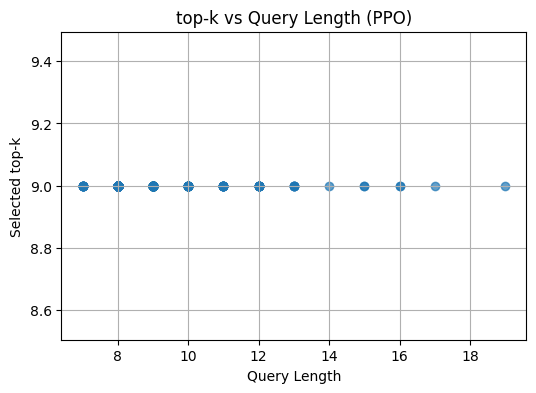

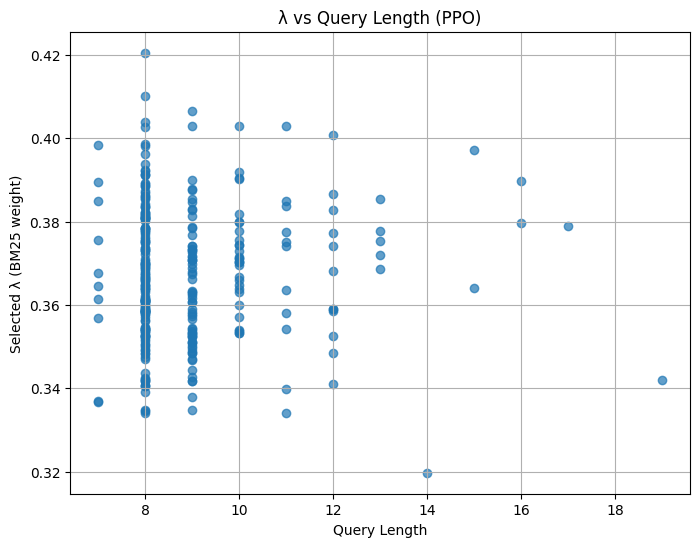

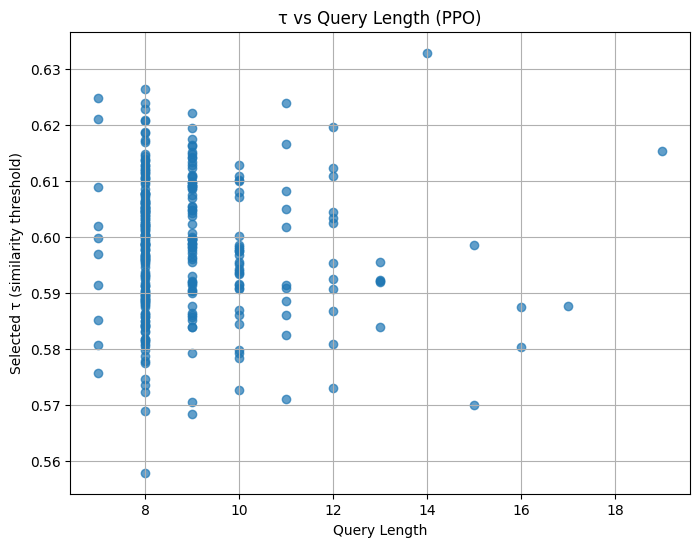

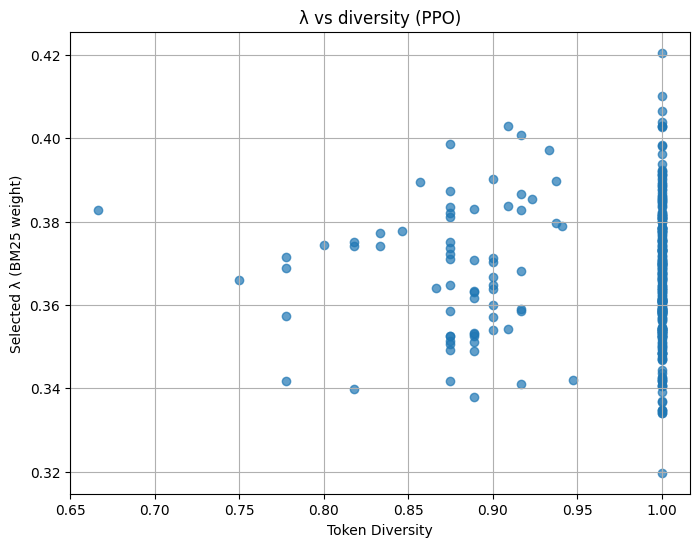

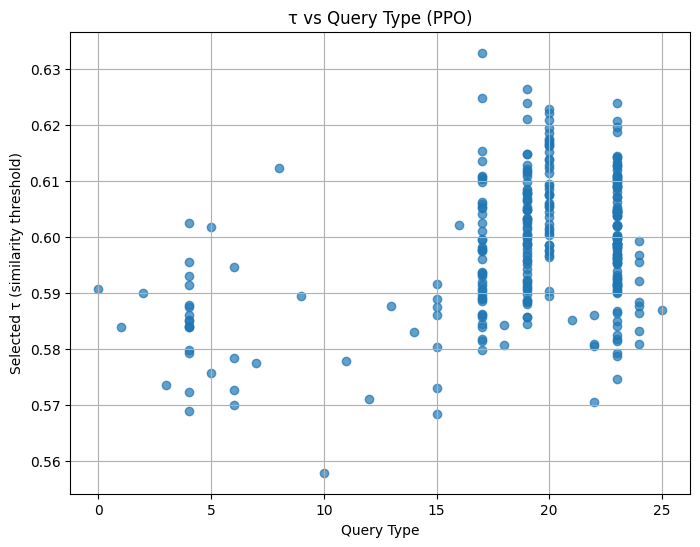

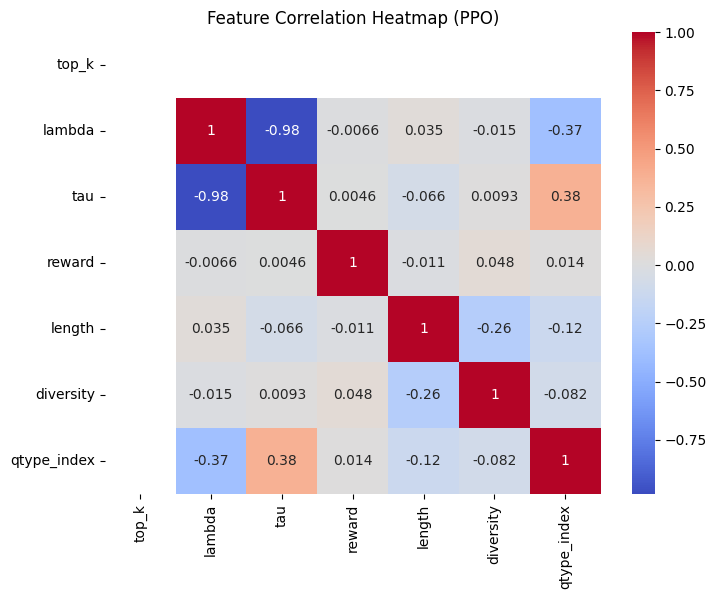

In [ ]:
import pandas as pd

ppo_df = pd.DataFrame(ppo_test_results)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(ppo_df["length"], ppo_df["top_k"], alpha=0.7)
plt.xlabel("Query Length")
plt.ylabel("Selected top-k")
plt.title("top-k vs Query Length (PPO)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(ppo_df["length"], ppo_df["lambda"], alpha=0.7)
plt.xlabel("Query Length")
plt.ylabel("Selected λ (BM25 weight)")
plt.title("λ vs Query Length (PPO)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(ppo_df["length"], ppo_df["tau"], alpha=0.7)
plt.xlabel("Query Length")
plt.ylabel("Selected τ (similarity threshold)")
plt.title("τ vs Query Length (PPO)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(ppo_df["diversity"], ppo_df["lambda"], alpha=0.7)
plt.xlabel("Token Diversity")
plt.ylabel("Selected λ (BM25 weight)")
plt.title("λ vs diversity (PPO)")
plt.grid(True)
plt.show()


ppo_df["qtype_index"] = ppo_df["qtype"].astype("category").cat.codes
plt.figure(figsize=(8,6))
plt.scatter(ppo_df["qtype_index"], ppo_df["tau"], alpha=0.7)
plt.xlabel("Query Type")
plt.ylabel("Selected τ (similarity threshold)")
plt.title("τ vs Query Type (PPO)")
plt.grid(True)
plt.show()



import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(ppo_df[["top_k", "lambda", "tau", "reward", "length", "diversity", "qtype_index"]].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap (PPO)")
plt.show()




In [ ]:
print(ppo_df[["top_k", "lambda", "tau", "reward", "length"]].corr())

        top_k    lambda       tau    reward    length
top_k     NaN       NaN       NaN       NaN       NaN
lambda    NaN  1.000000 -0.984092 -0.006631  0.035460
tau       NaN -0.984092  1.000000  0.004554 -0.065873
reward    NaN -0.006631  0.004554  1.000000 -0.010520
length    NaN  0.035460 -0.065873 -0.010520  1.000000


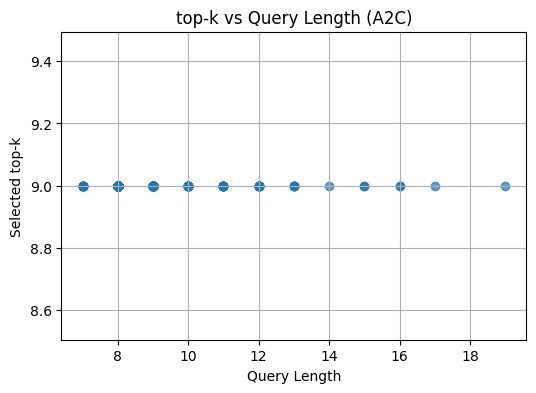

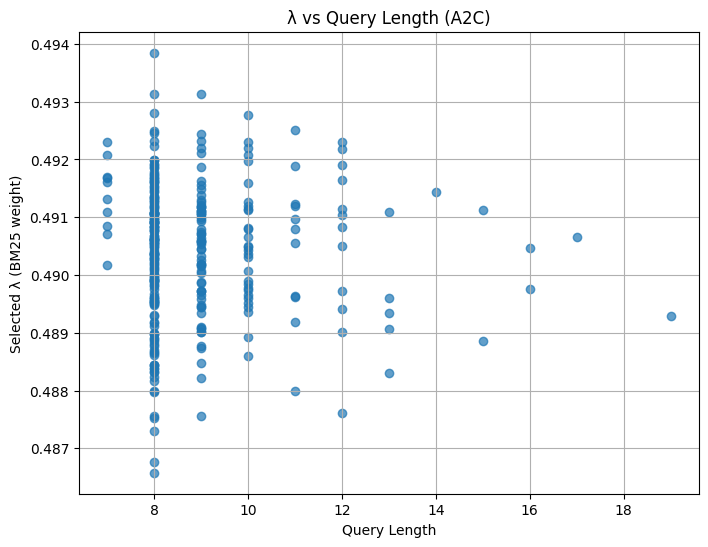

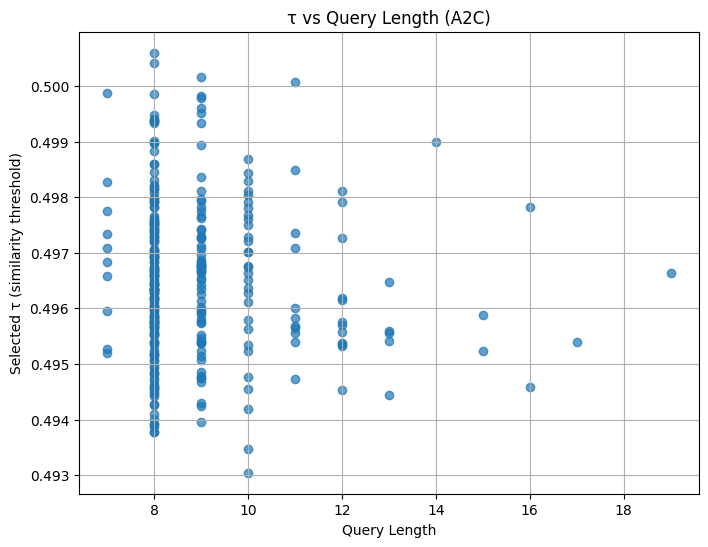

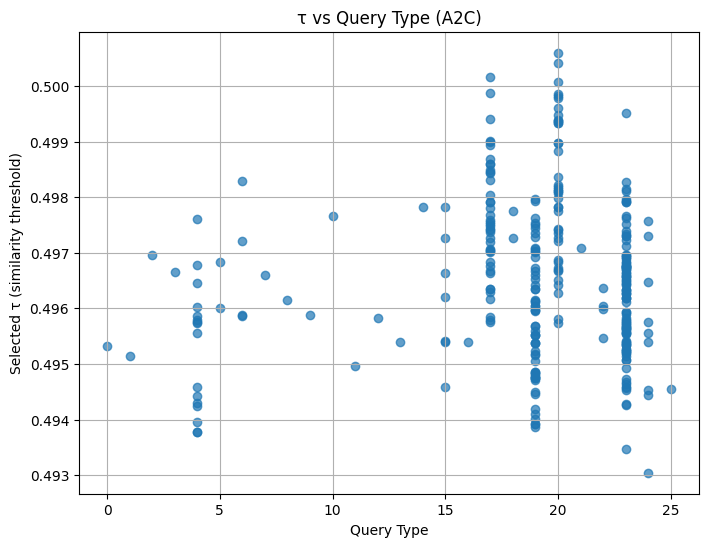

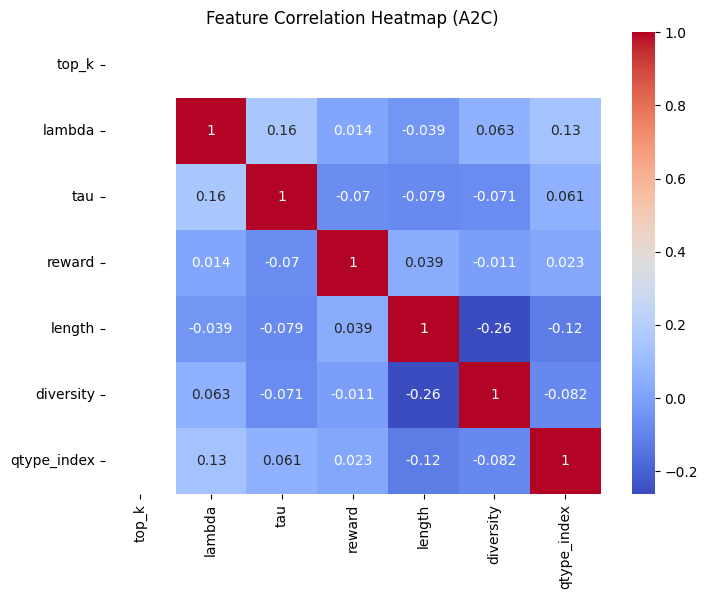

In [ ]:
import pandas as pd

a2c_df = pd.DataFrame(a2c_test_results)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(a2c_df["length"], a2c_df["top_k"], alpha=0.7)
plt.xlabel("Query Length")
plt.ylabel("Selected top-k")
plt.title("top-k vs Query Length (A2C)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(a2c_df["length"], a2c_df["lambda"], alpha=0.7)
plt.xlabel("Query Length")
plt.ylabel("Selected λ (BM25 weight)")
plt.title("λ vs Query Length (A2C)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(a2c_df["length"], a2c_df["tau"], alpha=0.7)
plt.xlabel("Query Length")
plt.ylabel("Selected τ (similarity threshold)")
plt.title("τ vs Query Length (A2C)")
plt.grid(True)
plt.show()

a2c_df["qtype_index"] = a2c_df["qtype"].astype("category").cat.codes
plt.figure(figsize=(8,6))
plt.scatter(a2c_df["qtype_index"], a2c_df["tau"], alpha=0.7)
plt.xlabel("Query Type")
plt.ylabel("Selected τ (similarity threshold)")
plt.title("τ vs Query Type (A2C)")
plt.grid(True)
plt.show()

import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(a2c_df[["top_k", "lambda", "tau", "reward", "length", "diversity", "qtype_index"]].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap (A2C)")
plt.show()




<ipython-input-44-05909f138914>:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_, labels=labels_, showmeans=True)  # show mean explicitly


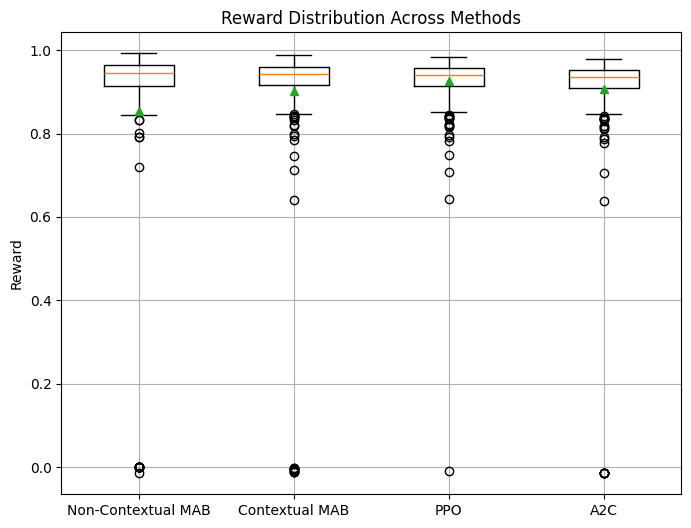

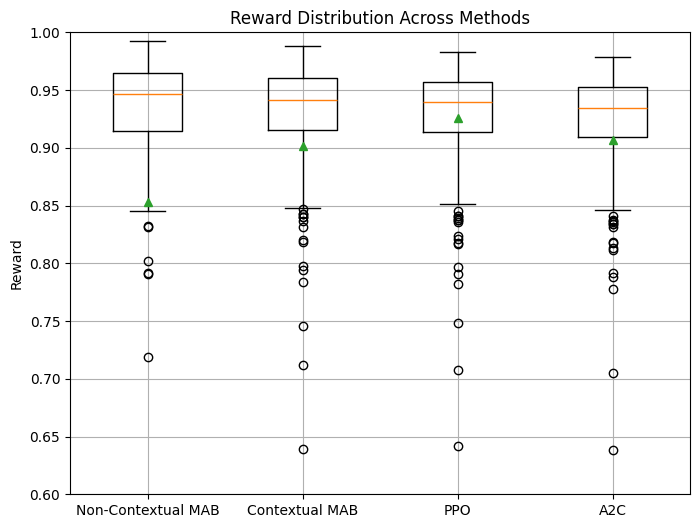

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Make sure each reward list is a 1D array
mab_rewards = np.array(mab_rewards).flatten()
cmab_rewards = np.array(cmab_rewards).flatten()
ppo_rewards = np.array(ppo_rewards).flatten()
a2c_rewards = np.array(a2c_rewards).flatten()


data_ = [mab_rewards, cmab_rewards, ppo_rewards, a2c_rewards]
labels_ = ['Non-Contextual MAB', 'Contextual MAB', 'PPO', 'A2C']

plt.figure(figsize=(8, 6))
plt.boxplot(data_, labels=labels_, showmeans=True)  # show mean explicitly
plt.title("Reward Distribution Across Methods")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

#plt.ylim(0, 1.0)
plt.show()

plt.figure(figsize=(8, 6))
plt.boxplot(data_, tick_labels=labels_, showmeans=True)  # <-- use tick_labels
plt.title("Reward Distribution Across Methods")
plt.ylabel("Reward")
plt.grid(True)

plt.ylim(0.6, 1.0)
plt.show()


In [ ]:
for name, rewards in zip(labels_, data_):
    print(f"{name}: Mean={np.mean(rewards):.4f}, Median={np.median(rewards):.4f}, Min={np.min(rewards):.4f}, Max={np.max(rewards):.4f}")


Non-Contextual MAB: Mean=0.8531, Median=0.9463, Min=-0.0150, Max=0.9925
Contextual MAB: Mean=0.9018, Median=0.9418, Min=-0.0125, Max=0.9880
PPO: Mean=0.9261, Median=0.9397, Min=-0.0105, Max=0.9829
A2C: Mean=0.9070, Median=0.9347, Min=-0.0142, Max=0.9783
